### Dummy Variables

You saw in the earlier notebook that you weren't able to directly add a categorical variable to your multiple linear regression model. In this notebook, you will get some practice incorporating categorical data by converting to dummy variables in your models and interpreting the output.

Let's start by reading in the necessary libraries and data.

In [31]:
import numpy as np
import pandas as pd
import statsmodels.api as sm;
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('./house_prices.csv')
df.head()

,house_id,neighborhood,area,bedrooms,bathrooms,style,price
0,1112,B,1188,3,2,ranch,598291
1,491,B,3512,5,3,victorian,1744259
2,5952,B,1134,3,2,ranch,571669
3,3525,A,1940,4,2,ranch,493675
4,5108,B,2208,6,4,victorian,1101539


`1.` Use the [pd.get_dummies](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html) documentation to assist you with obtaining dummy variables for the **neighborhood** column.  Then use [join](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.join.html) to add the dummy variables to your dataframe, **df**, and store the joined results in **df_new**.

Fit a linear model using **all three levels** of **neighborhood** to predict the price. Don't forget an intercept.

Use your results to answer quiz 1 below.

In [35]:
df_neighborhood = pd.get_dummies(df["neighborhood"], prefix="nhood", dtype=int)
df_new = df.join(df_neighborhood)
df_new["intercept"] = 1
df_new.head()

,house_id,neighborhood,area,bedrooms,bathrooms,style,price,nhood_A,nhood_B,nhood_C,intercept
0,1112,B,1188,3,2,ranch,598291,0,1,0,1
1,491,B,3512,5,3,victorian,1744259,0,1,0,1
2,5952,B,1134,3,2,ranch,571669,0,1,0,1
3,3525,A,1940,4,2,ranch,493675,1,0,0,1
4,5108,B,2208,6,4,victorian,1101539,0,1,0,1


In [36]:
lm_nhood = sm.OLS(df_new["price"], df_new[["intercept", "nhood_A", "nhood_B", "nhood_C"]])
results = lm_nhood.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     654.4
Date:                Wed, 12 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:27:57   Log-Likelihood:                -87083.
No. Observations:                6028   AIC:                         1.742e+05
Df Residuals:                    6024   BIC:                         1.742e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1.672e+17   1.36e+17      1.232      0.218   -9.88e+16    4.33e+17
nhood_A    -1.672e+17   1.36e+17     -1.232      0.218   -4.33e+17    9.88e+16
nhood_B    -1.672e+17   1.36e+17     -1.232      0.218   -4.33e+17    9.88e+16
nhood_C    -1.672e+17   1.36e+17     -1.232      0.218   -4.33e+17    9.88e+16
==============================================================================
Omnibus:                      718.938   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1216.906
Skew:                           0.816   Prob(JB):                    5.65e-265
Kurtosis:                       4.476   Cond. No.                     5.37e+13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.81e-24. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

`2.`  Now, fit an appropriate linear model for using **neighborhood** to predict the price of a home. Use **neighborhood A** as your baseline. (And remember that the values shown in the results for the other neighborhoods will be based on comparisons with this baseline neighborhood A then.) Use your resulting model to answer the questions in Quiz 2 and Quiz 3 below.

In [37]:
lm_nhood_A = sm.OLS(df_new["price"], df_new[["intercept", "nhood_B", "nhood_C"]])
lm_nhood_A_results = lm_nhood_A.fit()
lm_nhood_A_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     983.1
Date:                Wed, 12 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:32:58   Log-Likelihood:                -87082.
No. Observations:                6028   AIC:                         1.742e+05
Df Residuals:                    6025   BIC:                         1.742e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   5.411e+05   1.05e+04     51.537      0.000    5.21e+05    5.62e+05
nhood_B     5.295e+05    1.4e+04     37.870      0.000    5.02e+05    5.57e+05
nhood_C     -332.3594   1.52e+04     -0.022      0.983   -3.01e+04    2.94e+04
==============================================================================
Omnibus:                      689.315   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1154.155
Skew:                           0.793   Prob(JB):                    2.39e-251
Kurtosis:                       4.442   Cond. No.                         3.88
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

`3.` Run the two cells below to look at the home prices for the A and C neighborhoods. Add neighborhood B. This creates a glimpse into the differences that you found in the previous linear model.

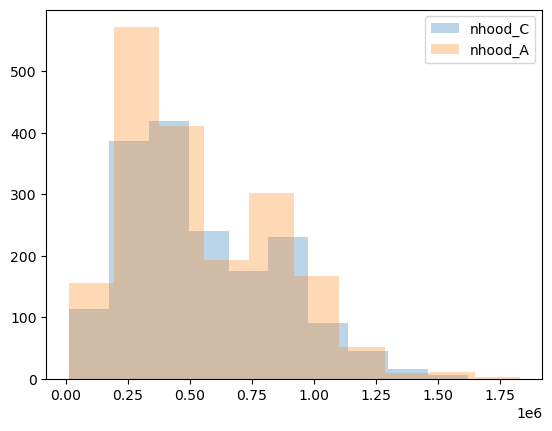

In [38]:
plt.hist(df_new.query("nhood_C == 1")['price'], alpha = 0.3, label = 'nhood_C');
plt.hist(df_new.query("nhood_A == 1")['price'], alpha = 0.3, label = 'nhood_A');

plt.legend();

`4.` Now, add dummy variables for the **style** of house. Create a new linear model using these new dummies, as well as the previous **neighborhood** dummies.  Use **ranch** as the baseline for the **style**.  Additionally, add **bathrooms** and **bedrooms** to your linear model.  Don't forget an intercept.  Use the results of your linear model to answer the last two questions below. **Home prices are measured in dollars, and this dataset is not real.**

To minimize scrolling, it might be useful to open another browser window to this concept to answer the quiz questions.

In [39]:
df_style = pd.get_dummies(df["style"], prefix="style", dtype=int)
df_new = df_new.join(df_style)

df_new.head()


,house_id,neighborhood,area,bedrooms,bathrooms,style,price,nhood_A,nhood_B,nhood_C,intercept,style_lodge,style_ranch,style_victorian
0,1112,B,1188,3,2,ranch,598291,0,1,0,1,0,1,0
1,491,B,3512,5,3,victorian,1744259,0,1,0,1,0,0,1
2,5952,B,1134,3,2,ranch,571669,0,1,0,1,0,1,0
3,3525,A,1940,4,2,ranch,493675,1,0,0,1,0,1,0
4,5108,B,2208,6,4,victorian,1101539,0,1,0,1,0,0,1


In [41]:
lm_style_ranch = sm.OLS(df_new["price"], df_new[["intercept", "bathrooms", "bedrooms", "nhood_A", "nhood_B", "nhood_C", "style_lodge", "style_victorian"]])
lm_style_ranch_results = lm_style_ranch.fit()
lm_style_ranch_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     4250.
Date:                Wed, 12 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:43:38   Log-Likelihood:                -82944.
No. Observations:                6028   AIC:                         1.659e+05
Df Residuals:                    6021   BIC:                         1.659e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
intercept       -1.585e+05   8352.235    -18.980      0.000   -1.75e+05   -1.42e+05
bathrooms        9.996e+04   1.09e+04      9.164      0.000    7.86e+04    1.21e+05
bedrooms         1.732e+05   7677.152     22.558      0.000    1.58e+05    1.88e+05
nhood_A         -2.248e+05   5126.308    -43.845      0.000   -2.35e+05   -2.15e+05
nhood_B          2.982e+05   4784.834     62.316      0.000    2.89e+05    3.08e+05
nhood_C         -2.319e+05   5233.875    -44.314      0.000   -2.42e+05   -2.22e+05
style_lodge      1.685e+05   9906.629     17.012      0.000    1.49e+05    1.88e+05
style_victorian  7.056e+04   8337.790      8.463      0.000    5.42e+04    8.69e+04
==============================================================================
Omnibus:                      978.611   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2926.472
Skew:                           0.848   Prob(JB):                         0.00
Kurtosis:                       5.962   Cond. No.                     1.56e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 5.99e-26. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""